In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','no-latex', 'notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [4]:
def compute_IG(imbalances, correction=True):
    imb_gain = (imbalances[:,:,0] - np.min(imbalances, axis=-1)) / imbalances[:,:,0]
    if correction:
        mask = imbalances[:,:,0] > 1
        imb_gain[mask] = 0
    return imb_gain

### Lorenz 96, all coordinates

In [8]:
epsilons_zx = np.arange(0.,3+0.2,0.2)
print(f"epsilons_zx = {epsilons_zx}")
alphas = np.linspace(0.,1.5,300)
taus_forward = np.array([1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 50, 70, 100, 200, 
                300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500])
taus_backward = -np.flip(taus_forward)
taus = np.append(taus_backward,taus_forward)

# X and Y
info_imbalances_X_to_Y = np.zeros((len(epsilons_zx),len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(epsilons_zx),len(taus),len(alphas)))
for i_eps, eps in enumerate(epsilons_zx):
    _, info_imbalances_X_to_Y[i_eps], info_imbalances_Y_to_X[i_eps] = pickle.load(open(f"./ig_scripts/pickles/XY_ieps{i_eps}.p","rb"))
IGs_X_to_Y = compute_IG(info_imbalances_X_to_Y)
IGs_Y_to_X = compute_IG(info_imbalances_Y_to_X)

# Z and Y
info_imbalances_Z_to_Y = np.zeros((len(epsilons_zx),len(taus),len(alphas)))
info_imbalances_Y_to_Z = np.zeros((len(epsilons_zx),len(taus),len(alphas)))
for i_eps, eps in enumerate(epsilons_zx):
    _, info_imbalances_Z_to_Y[i_eps], info_imbalances_Y_to_Z[i_eps] = pickle.load(open(f"./ig_scripts/pickles/ZY_ieps{i_eps}_noembforZ.p","rb"))
IGs_Z_to_Y = compute_IG(info_imbalances_Z_to_Y)
IGs_Y_to_Z = compute_IG(info_imbalances_Y_to_Z)

# Z and X
info_imbalances_Z_to_X = np.zeros((len(epsilons_zx),len(taus),len(alphas)))
info_imbalances_X_to_Z = np.zeros((len(epsilons_zx),len(taus),len(alphas)))
for i_eps, eps in enumerate(epsilons_zx):
    _, info_imbalances_Z_to_X[i_eps], info_imbalances_X_to_Z[i_eps] = pickle.load(open(f"./ig_scripts/pickles/ZX_ieps{i_eps}_noembforZ.p","rb"))
IGs_Z_to_X = compute_IG(info_imbalances_Z_to_X)
IGs_X_to_Z = compute_IG(info_imbalances_X_to_Z)

epsilons_zx = [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3. ]


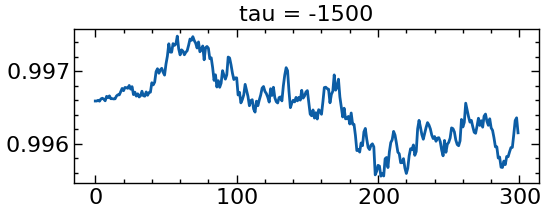

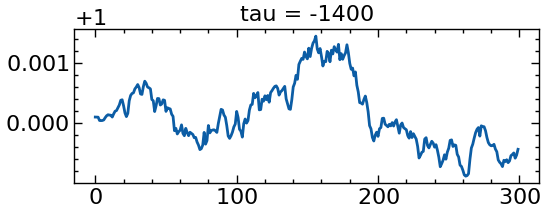

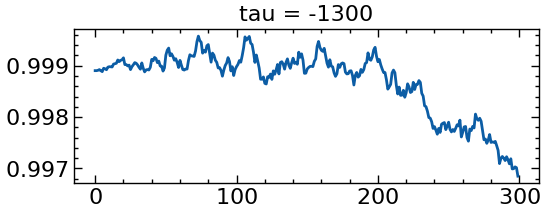

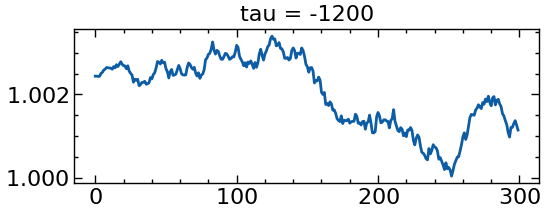

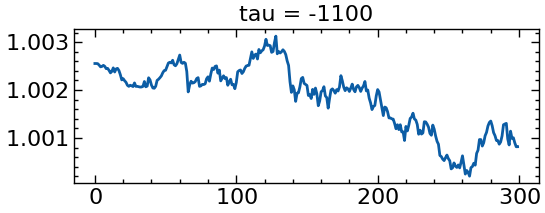

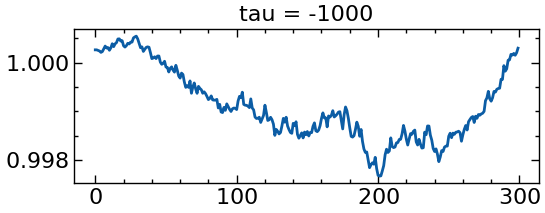

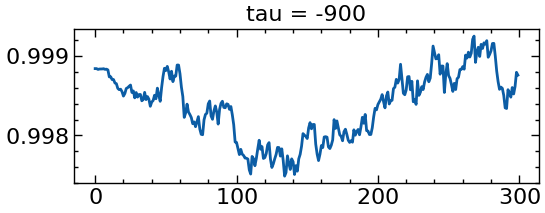

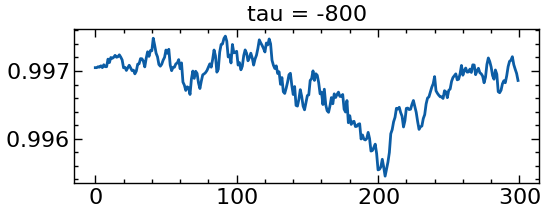

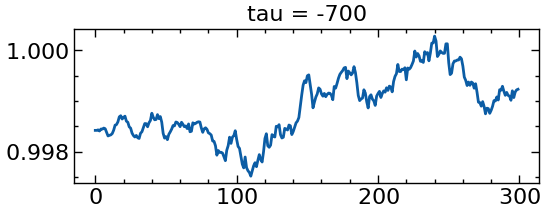

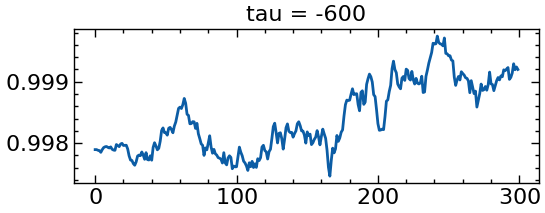

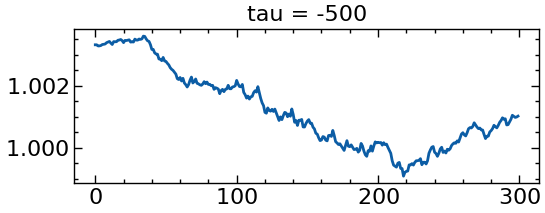

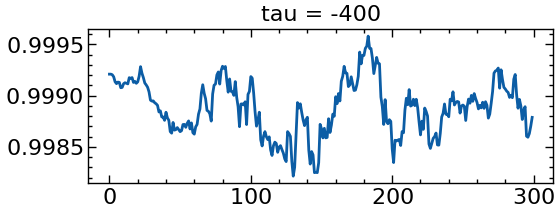

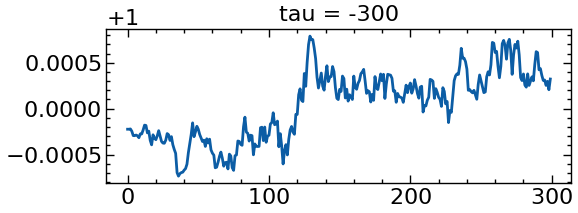

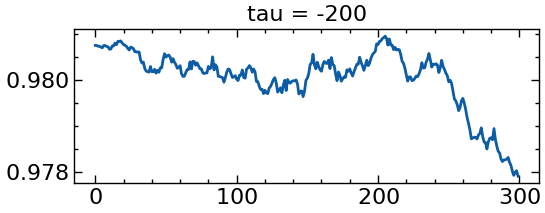

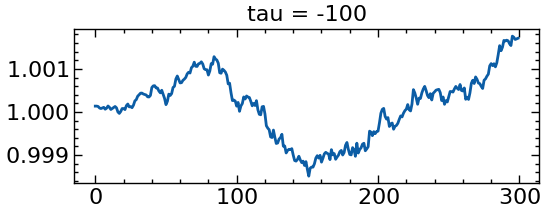

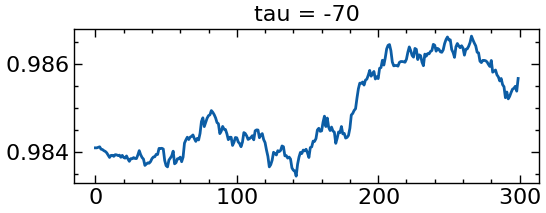

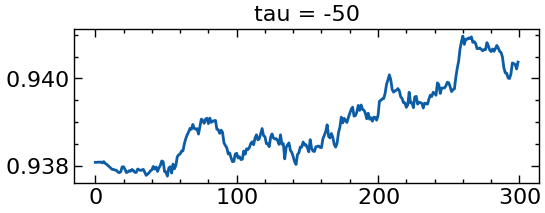

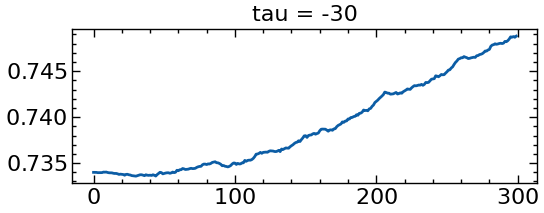

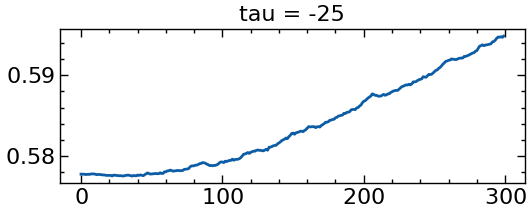

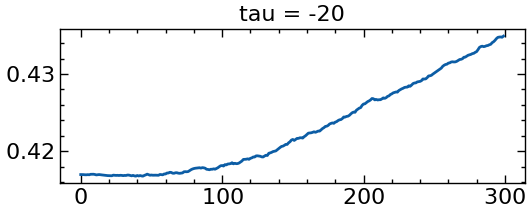

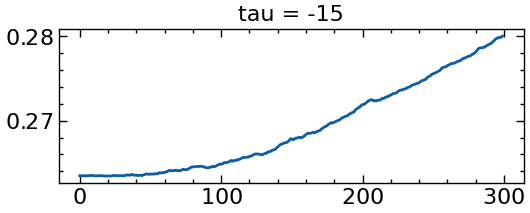

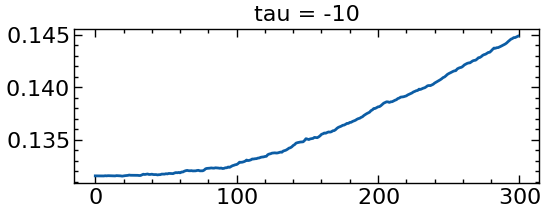

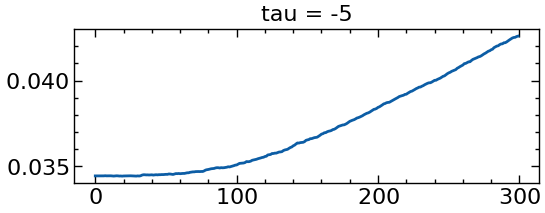

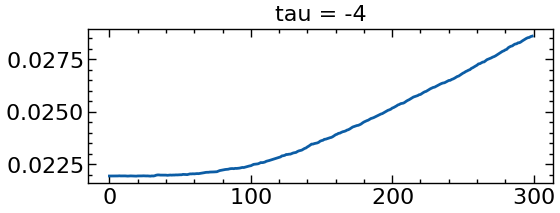

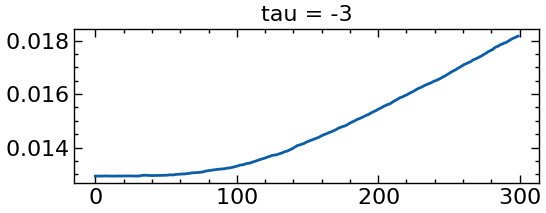

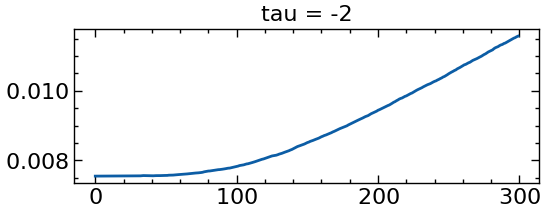

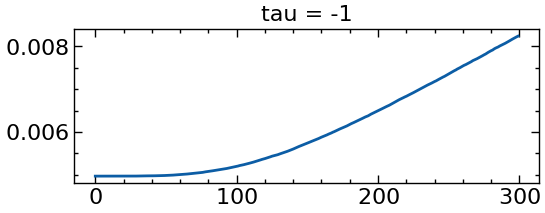

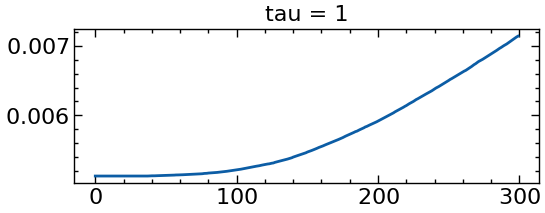

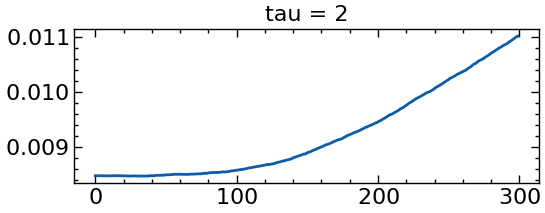

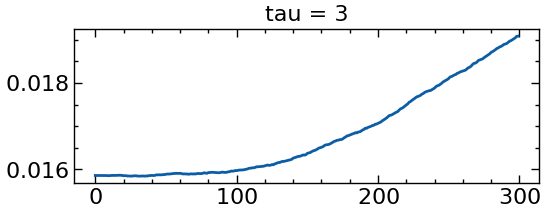

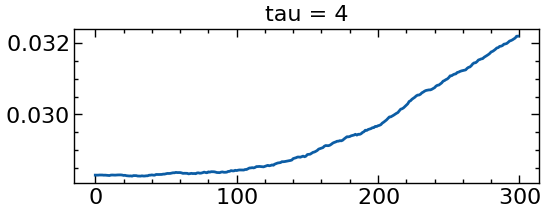

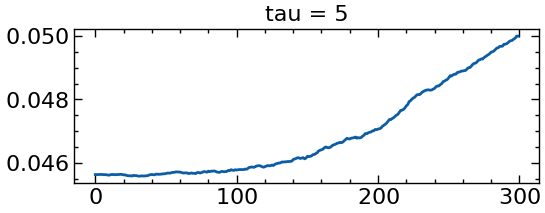

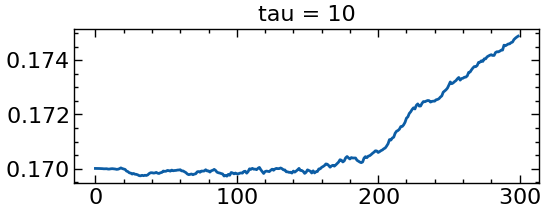

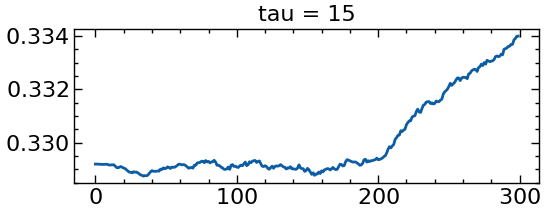

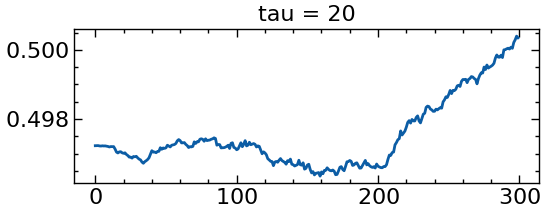

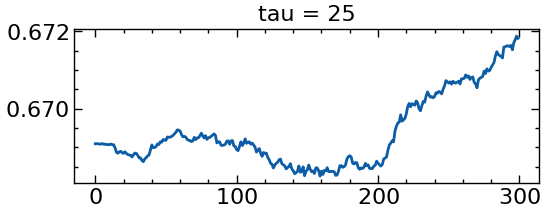

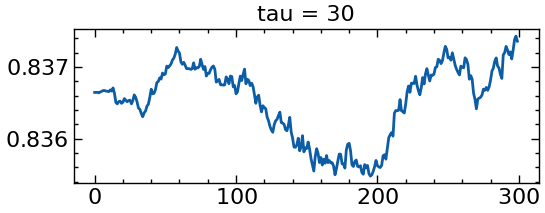

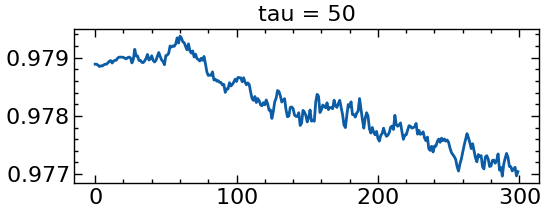

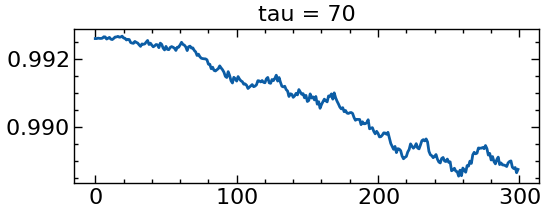

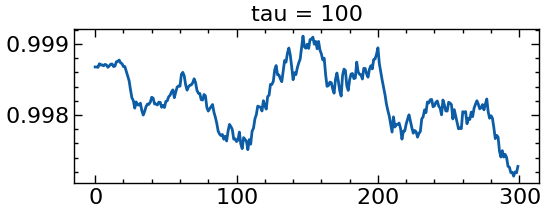

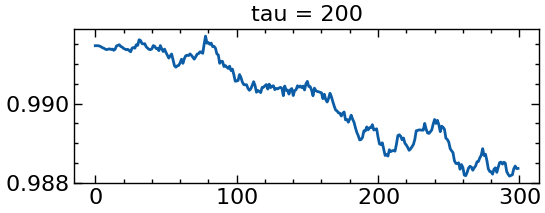

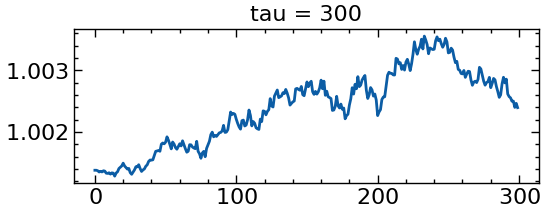

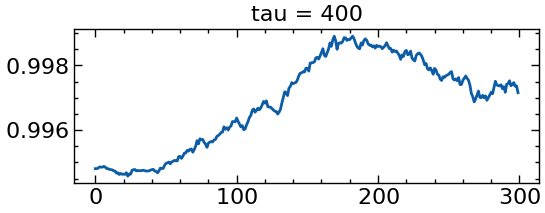

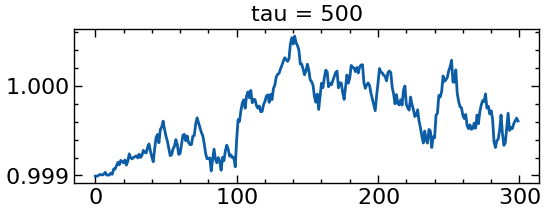

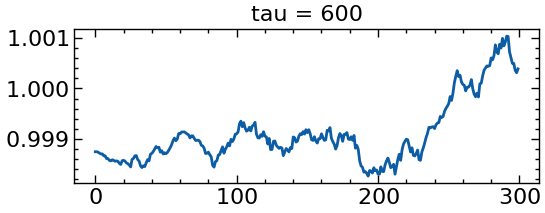

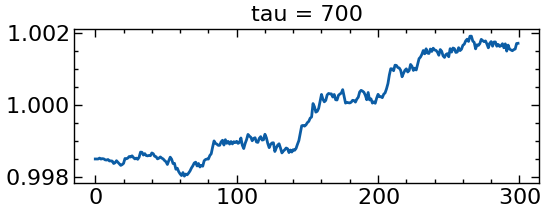

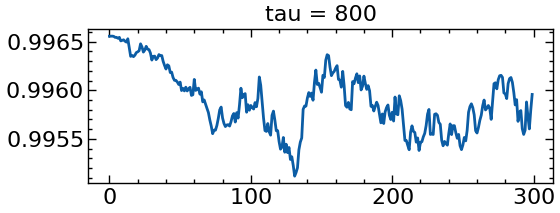

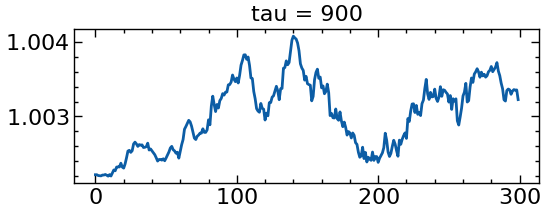

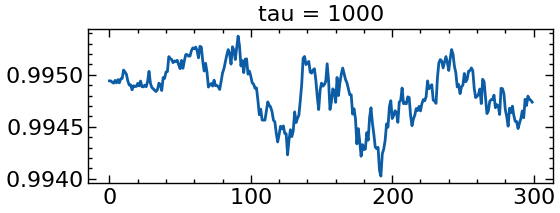

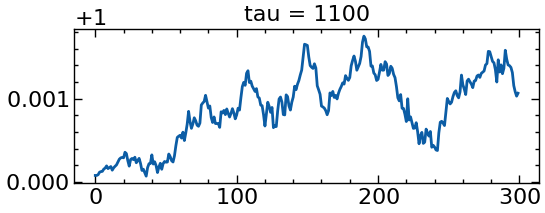

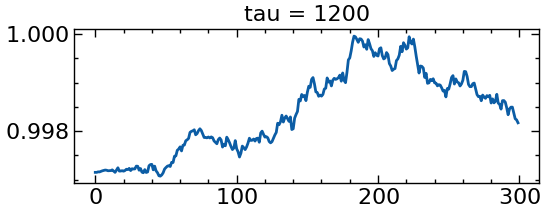

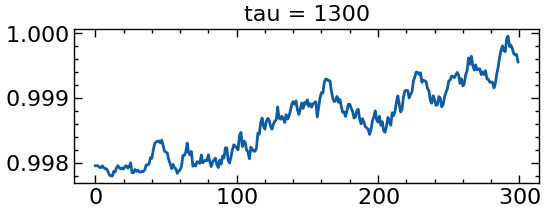

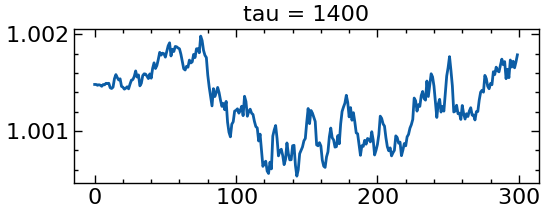

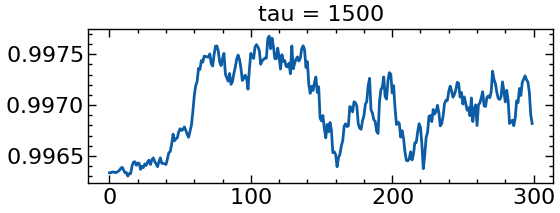

In [10]:
for i_tau, tau in enumerate(taus):
    plt.figure(figsize=(6,2))
    plt.plot(info_imbalances_Z_to_Y[10][i_tau])
    plt.title(f"tau = {tau}")
    plt.show()

### plots

Tested epsilon_zx = 2.0


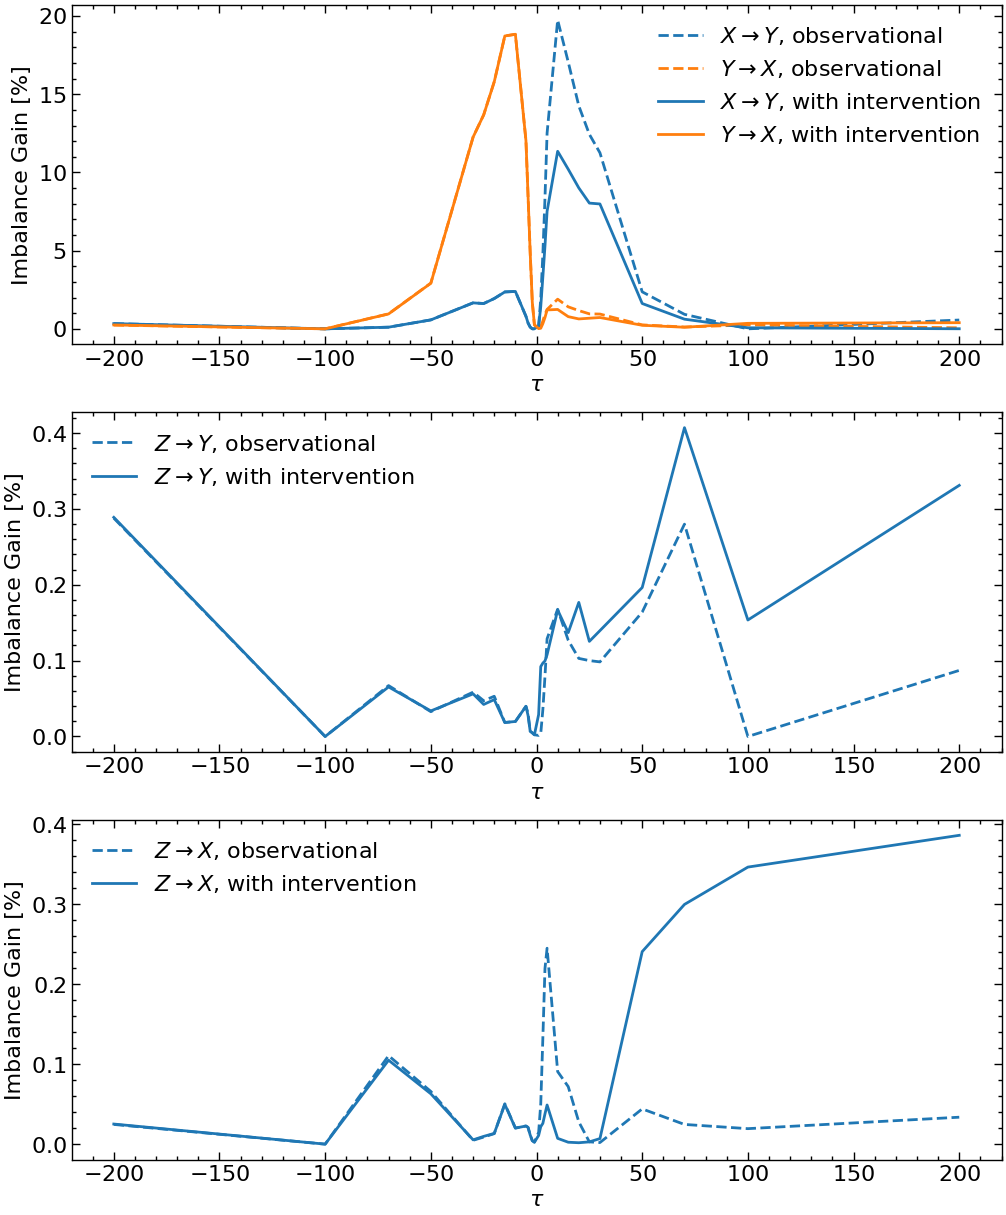

In [11]:
ieps = 10
print(f"Tested epsilon_zx = {epsilons_zx[ieps]}")

fig, ax = plt.subplots(3,1,figsize=(12,15))
n_skip = 13

############################### X and Y ###############################
ax[0].plot(taus[n_skip:-n_skip], 100*IGs_X_to_Y[0][n_skip:-n_skip], '--', color="tab:blue", label="$X\\rightarrow Y$, observational")
ax[0].plot(taus[n_skip:-n_skip], 100*IGs_Y_to_X[0][n_skip:-n_skip], '--', color="tab:orange", label="$Y\\rightarrow X$, observational")
ax[0].plot(taus[n_skip:-n_skip], 100*IGs_X_to_Y[ieps][n_skip:-n_skip], '-', color="tab:blue", label="$X\\rightarrow Y$, with intervention")
ax[0].plot(taus[n_skip:-n_skip], 100*IGs_Y_to_X[ieps][n_skip:-n_skip], '-', color="tab:orange", label="$Y\\rightarrow X$, with intervention")
ax[0].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]")
#ax[0].set(xscale="log")
ax[0].legend()

############################### Z and Y ###############################
ax[1].plot(taus[n_skip:-n_skip], 100*IGs_Z_to_Y[0][n_skip:-n_skip], '--', color="tab:blue", label="$Z\\rightarrow Y$, observational")
#ax[1].plot(taus[n_skip:-n_skip], 100*IGs_Y_to_Z[0][n_skip:-n_skip], '--', color="tab:orange", label="$Y\\rightarrow Z$, observational")
ax[1].plot(taus[n_skip:-n_skip], 100*IGs_Z_to_Y[ieps][n_skip:-n_skip], '-', color="tab:blue", label="$Z\\rightarrow Y$, with intervention")
#ax[1].plot(taus[n_skip:-n_skip], 100*IGs_Y_to_Z[ieps][n_skip:-n_skip], '-', color="tab:orange", label="$Y\\rightarrow Z$, with intervention")
ax[1].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]")
ax[1].legend()

############################### Z and X ###############################
ax[2].plot(taus[n_skip:-n_skip], 100*IGs_Z_to_X[0][n_skip:-n_skip], '--', color="tab:blue", label="$Z\\rightarrow X$, observational")
#ax[2].plot(taus[n_skip:-n_skip], 100*IGs_X_to_Z[0][n_skip:-n_skip], '--', color="tab:orange", label="$X\\rightarrow Z$, observational")
ax[2].plot(taus[n_skip:-n_skip], 100*IGs_Z_to_X[ieps][n_skip:-n_skip], '-', color="tab:blue", label="$Z\\rightarrow X$, with intervention")
#ax[2].plot(taus[n_skip:-n_skip], 100*IGs_X_to_Z[ieps][n_skip:-n_skip], '-', color="tab:orange", label="$X\\rightarrow Z$, with intervention")
ax[2].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]")
ax[2].legend()

plt.savefig("./figures/eps_zx_3.pdf", dpi=300)
plt.show()

In [12]:
np.random.random(size=10)

array([0.79799036, 0.06565718, 0.86763212, 0.55369914, 0.97424934,
       0.08356536, 0.87156081, 0.6880748 , 0.13540294, 0.49521863])

Tested epsilon_zx = 3.0


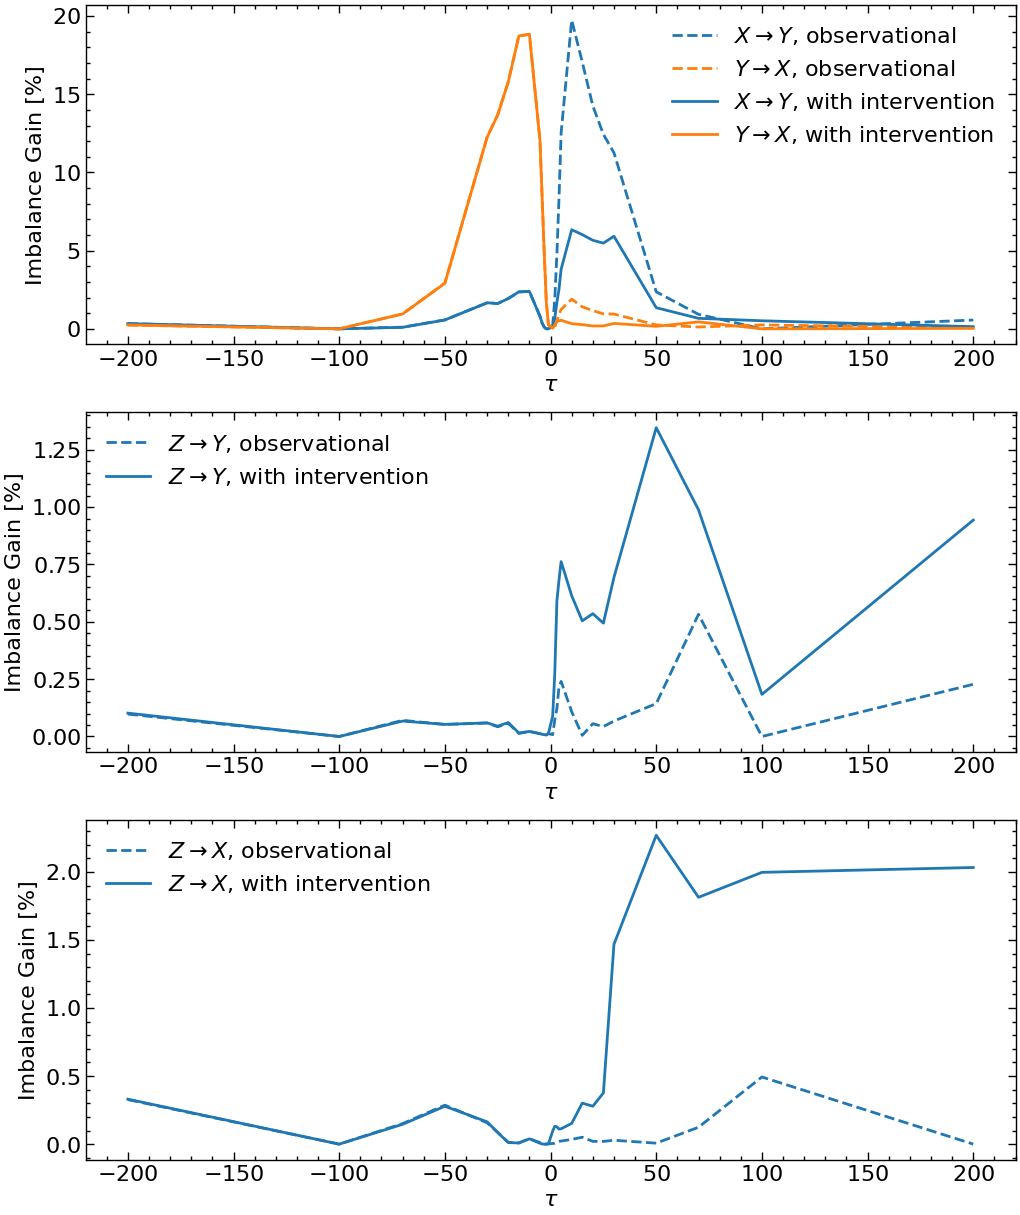

In [ ]:
ieps = 15
print(f"Tested epsilon_zx = {epsilons_zx[ieps]}")

fig, ax = plt.subplots(3,1,figsize=(12,15))
n_skip = 13

############################### X and Y ###############################
ax[0].plot(taus[n_skip:-n_skip], 100*IGs_X_to_Y[0][n_skip:-n_skip], '--', color="tab:blue", label="$X\\rightarrow Y$, observational")
ax[0].plot(taus[n_skip:-n_skip], 100*IGs_Y_to_X[0][n_skip:-n_skip], '--', color="tab:orange", label="$Y\\rightarrow X$, observational")
ax[0].plot(taus[n_skip:-n_skip], 100*IGs_X_to_Y[ieps][n_skip:-n_skip], '-', color="tab:blue", label="$X\\rightarrow Y$, with intervention")
ax[0].plot(taus[n_skip:-n_skip], 100*IGs_Y_to_X[ieps][n_skip:-n_skip], '-', color="tab:orange", label="$Y\\rightarrow X$, with intervention")
ax[0].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]")
#ax[0].set(xscale="log")
ax[0].legend()

############################### Z and Y ###############################
ax[1].plot(taus[n_skip:-n_skip], 100*IGs_Z_to_Y[0][n_skip:-n_skip], '--', color="tab:blue", label="$Z\\rightarrow Y$, observational")
#ax[1].plot(taus[n_skip:-n_skip], 100*IGs_Y_to_Z[0][n_skip:-n_skip], '--', color="tab:orange", label="$Y\\rightarrow Z$, observational")
ax[1].plot(taus[n_skip:-n_skip], 100*IGs_Z_to_Y[ieps][n_skip:-n_skip], '-', color="tab:blue", label="$Z\\rightarrow Y$, with intervention")
#ax[1].plot(taus[n_skip:-n_skip], 100*IGs_Y_to_Z[ieps][n_skip:-n_skip], '-', color="tab:orange", label="$Y\\rightarrow Z$, with intervention")
ax[1].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]")
ax[1].legend()

############################### Z and X ###############################
ax[2].plot(taus[n_skip:-n_skip], 100*IGs_Z_to_X[0][n_skip:-n_skip], '--', color="tab:blue", label="$Z\\rightarrow X$, observational")
#ax[2].plot(taus[n_skip:-n_skip], 100*IGs_X_to_Z[0][n_skip:-n_skip], '--', color="tab:orange", label="$X\\rightarrow Z$, observational")
ax[2].plot(taus[n_skip:-n_skip], 100*IGs_Z_to_X[ieps][n_skip:-n_skip], '-', color="tab:blue", label="$Z\\rightarrow X$, with intervention")
#ax[2].plot(taus[n_skip:-n_skip], 100*IGs_X_to_Z[ieps][n_skip:-n_skip], '-', color="tab:orange", label="$X\\rightarrow Z$, with intervention")
ax[2].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]")
ax[2].legend()

plt.savefig("./figures/eps_zx_3.pdf", dpi=300)
plt.show()